# 02 - CRF models for NER (3 versions)
**NLP Deliverable 2 — classical ML approach**

We train **three Conditional Random Field** models of increasing feature richness with
`sklearn-crfsuite`, to show how handcrafted feature engineering improves results:

1. **CRF v1 — baseline**: minimal features.
2. **CRF v2 — improved**: + affixes, word-shape flags and ±1 context.
3. **CRF v3 — fabulous**: + ±2 context, multi-length affixes, normalized word shape,
   orthographic flags and tuned regularization.

All three are saved to `fitted_models/` and re-loaded in `05_reproduce_results.ipynb`.

> Colab-friendly: installs `sklearn-crfsuite` and auto-detects the data path.

In [1]:
# === Setup (works locally and on Google Colab) ===
import sys, os
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install -q sklearn-crfsuite seqeval
    DATA_DIR = '.'                  # adjust to where you uploaded the CSVs
else:
    DATA_DIR = '../nlp_d2_data'
FITTED_DIR = 'fitted_models'
os.makedirs(FITTED_DIR, exist_ok=True)

import warnings; warnings.filterwarnings('ignore')
import re, pickle
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import sklearn_crfsuite
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
sns.set_theme(style='whitegrid')

## 1. Load data (grouped by sentence)

In [2]:
def load_data(path):
    """Read a token-level NER CSV and return a list of sentences,
    each a list of (word, tag) tuples, grouped by sentence_id."""
    df = pd.read_csv(path)
    df['words'] = df['words'].astype(str)
    df['sentence_id'] = df['sentence_id'].astype(int)
    sents = []
    for _, g in df.groupby('sentence_id', sort=True):
        sents.append(list(zip(g['words'].tolist(), g['tags'].tolist())))
    return sents

train_sents = load_data(os.path.join(DATA_DIR, 'train_data_ner.csv'))
test_sents  = load_data(os.path.join(DATA_DIR, 'test_data_ner.csv'))
print(f'train: {len(train_sents)} sentences | test: {len(test_sents)} sentences')

train: 38366 sentences | test: 38367 sentences


## 2. Feature templates (3 levels)

In [3]:
def word_shape(w):
    s = re.sub('[A-Z]', 'X', w)
    s = re.sub('[a-z]', 'x', s)
    s = re.sub('[0-9]', 'd', s)
    return s

def feat_v1(sent, i):
    w = str(sent[i][0])
    return {
        'bias': 1.0,
        'w.lower': w.lower(),
        'w.isupper': w.isupper(),
        'w.istitle': w.istitle(),
        'w.isdigit': w.isdigit(),
    }

def feat_v2(sent, i):
    w = str(sent[i][0])
    f = {
        'bias': 1.0,
        'w.lower': w.lower(),
        'w[-3:]': w[-3:], 'w[-2:]': w[-2:], 'w[:3]': w[:3],
        'w.isupper': w.isupper(), 'w.istitle': w.istitle(), 'w.isdigit': w.isdigit(),
        'w.shape': word_shape(w),
    }
    if i > 0:
        p = str(sent[i-1][0])
        f.update({'-1:lower': p.lower(), '-1:istitle': p.istitle(), '-1:isupper': p.isupper()})
    else:
        f['BOS'] = True
    if i < len(sent)-1:
        n = str(sent[i+1][0])
        f.update({'+1:lower': n.lower(), '+1:istitle': n.istitle(), '+1:isupper': n.isupper()})
    else:
        f['EOS'] = True
    return f

def feat_v3(sent, i):
    w = str(sent[i][0])
    f = {
        'bias': 1.0,
        'w.lower': w.lower(),
        'w[-4:]': w[-4:], 'w[-3:]': w[-3:], 'w[-2:]': w[-2:],
        'w[:2]': w[:2], 'w[:3]': w[:3],
        'w.isupper': w.isupper(), 'w.istitle': w.istitle(), 'w.isdigit': w.isdigit(),
        'w.shape': word_shape(w),
        'w.len': len(w),
        'w.has_hyphen': '-' in w,
        'w.has_digit': any(ch.isdigit() for ch in w),
        'w.is_punct': not any(ch.isalnum() for ch in w),
    }
    for off in (-2, -1, 1, 2):
        j = i + off
        if 0 <= j < len(sent):
            c = str(sent[j][0])
            f.update({
                f'{off:+d}:lower': c.lower(),
                f'{off:+d}:istitle': c.istitle(),
                f'{off:+d}:isupper': c.isupper(),
                f'{off:+d}:shape': word_shape(c),
            })
    if i == 0: f['BOS'] = True
    if i == len(sent)-1: f['EOS'] = True
    return f

def sent2labels(sent):
    return [t for _, t in sent]

FEATURES = {'v1': feat_v1, 'v2': feat_v2, 'v3': feat_v3}

## 3. Train the three CRFs and save them

In [4]:
y_train = [sent2labels(s) for s in train_sents]
y_test  = [sent2labels(s) for s in test_sents]

# v3 uses a bit stronger regularization tuning than the v1/v2 defaults
PARAMS = {
    'v1': dict(c1=0.1, c2=0.1, max_iterations=100),
    'v2': dict(c1=0.1, c2=0.1, max_iterations=100),
    'v3': dict(c1=0.2, c2=0.05, max_iterations=150),
}

crfs = {}
for v, featfn in FEATURES.items():
    X_train = [[featfn(s, i) for i in range(len(s))] for s in train_sents]
    crf = sklearn_crfsuite.CRF(algorithm='lbfgs',
                               all_possible_transitions=True,
                               **PARAMS[v])
    crf.fit(X_train, y_train)
    with open(os.path.join(FITTED_DIR, f'crf_{v}.pkl'), 'wb') as fh:
        pickle.dump(crf, fh)
    crfs[v] = crf
    print(f'CRF {v} trained ({len(crf.classes_)} classes) and saved.')

CRF v1 trained (17 classes) and saved.


CRF v2 trained (17 classes) and saved.


CRF v3 trained (17 classes) and saved.


## 4. Evaluation helpers

In [5]:
def flatten(seq):
    return [x for sub in seq for x in sub]

def non_o_accuracy(y_true, y_pred):
    yt, yp = flatten(y_true), flatten(y_pred)
    idx = [k for k, t in enumerate(yt) if t != 'O']
    return accuracy_score([yt[k] for k in idx], [yp[k] for k in idx])

def weighted_f1(y_true, y_pred, exclude_O=True):
    yt, yp = flatten(y_true), flatten(y_pred)
    labels = sorted(set(yt) - ({'O'} if exclude_O else set()))
    return f1_score(yt, yp, average='weighted', labels=labels, zero_division=0)

def predict(crf, sents, featfn):
    X = [[featfn(s, i) for i in range(len(s))] for s in sents]
    return crf.predict(X)

def plot_cm(y_true, y_pred, title):
    yt, yp = flatten(y_true), flatten(y_pred)
    labels = sorted(set(yt) - {'O'})
    cm = confusion_matrix(yt, yp, labels=labels)
    plt.figure(figsize=(9,7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title(title); plt.ylabel('True'); plt.xlabel('Predicted')
    plt.show()

## 5. Train/Test metrics for the three models

In [6]:
rows = []
preds_test = {}
for v, featfn in FEATURES.items():
    crf = crfs[v]
    yp_tr = predict(crf, train_sents, featfn)
    yp_te = predict(crf, test_sents, featfn)
    preds_test[v] = yp_te
    rows.append({
        'model': f'CRF {v}',
        'train_acc_nonO': non_o_accuracy(y_train, yp_tr),
        'test_acc_nonO':  non_o_accuracy(y_test,  yp_te),
        'train_f1':       weighted_f1(y_train, yp_tr),
        'test_f1':        weighted_f1(y_test,  yp_te),
    })
results = pd.DataFrame(rows).set_index('model').round(4)
display(results)

,train_acc_nonO,test_acc_nonO,train_f1,test_f1
model,,,,
CRF v1,0.8645,0.4774,0.8764,0.4770
CRF v2,0.9306,0.7051,0.9339,0.7271
CRF v3,0.9630,0.7316,0.9649,0.7531


### Confusion matrix on the test set — best model (CRF v3)

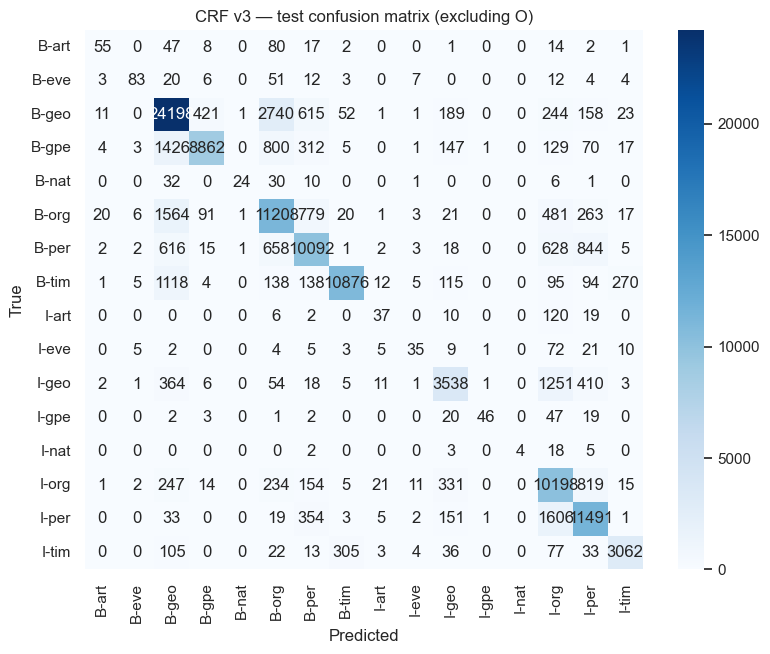

In [7]:
plot_cm(y_test, preds_test['v3'], 'CRF v3 — test confusion matrix (excluding O)')

## 6. TINY TEST predictions

In [8]:
tiny_sents = load_data(os.path.join(DATA_DIR, 'tiny_test.csv'))

def print_tiny(crf, featfn, sents, name):
    print(f'=== TINY TEST — {name} ===')
    y_true = [sent2labels(s) for s in sents]
    y_pred = predict(crf, sents, featfn)
    for s, pred in zip(sents, y_pred):
        print(' '.join(f'{w}/{t}' for (w, _), t in zip(s, pred)))
    print(f'Tiny-test accuracy (non-O): {non_o_accuracy(y_true, y_pred):.4f}\n')

for v, featfn in FEATURES.items():
    print_tiny(crfs[v], featfn, tiny_sents, f'CRF {v}')

=== TINY TEST — CRF v1 ===
The/O programmers/O from/O Barcelona/B-geo might/O write/O a/O sentence/O without/O a/O spell/O checker/O ./O
The/O programmers/O from/O Barchelona/B-geo cannot/O write/O a/O sentence/O without/O a/O spell/O checker/O ./O
Jack/B-per London/B-geo went/O to/O Parris/B-geo ./O
Jack/B-per London/B-geo went/O to/O Paris/B-geo ./O
Bill/B-per gates/I-per and/O Steve/B-per jobs/O never/O thought/O Microsoft/B-org would/O become/O such/O a/O big/O company/O ./O
Bill/B-per Gates/I-per and/O Steve/B-per Jobs/I-per never/O thought/O Microsoft/B-org would/O become/O such/O a/O big/O company/O ./O
The/O president/O of/O U.S.A/B-org thought/O they/O could/O win/O the/O war/O ./O
The/O president/O of/O the/O United/B-geo States/I-geo of/I-geo America/I-geo thought/O they/O could/O win/O the/O war/O ./O
The/O king/O of/O Saudi/B-geo Arabia/I-geo wanted/O total/O control/O ./O
Robin/O does/O not/O want/O to/O go/O to/O Saudi/B-geo Arabia/I-geo ./O
Apple/O is/O a/O great/O comp

## 7. Observations
- Each feature level should improve the non-`O` accuracy and weighted F1 on the test set.
- The richest model (**CRF v3**) is expected to handle rare/orthographic cases best
  (word-shape, affixes, wider context).
- Trained models are persisted in `fitted_models/` (`crf_v1.pkl`, `crf_v2.pkl`,
  `crf_v3.pkl`) and evaluated again in `05_reproduce_results.ipynb`.